# SVD : decomposition of an image

Shape of the image: (512, 512).
The number of bytes required to memorise the image Xk is: 262144.


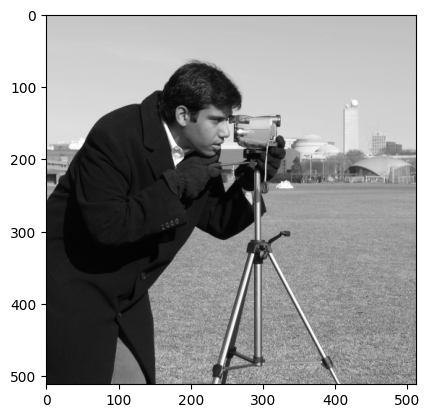

In [44]:
# USE python3.11.7 !!!!!!!!!

import skimage  # i can't install it in python3.13
import numpy as np

# Loading the "cameraman" image
x = skimage.data.camera()
m, n = x.shape

# Printing its shape
print(f"Shape of the image: {x.shape}.")
print(f"The number of bytes required to memorise the image Xk is: {m*n}.")

# Visualize the image
import matplotlib.pyplot as plt

plt.imshow(x, cmap="gray")
plt.show()


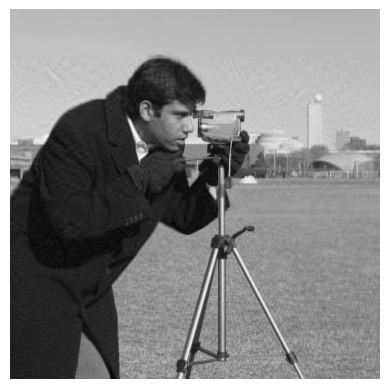

The number of bytes required to memorize the image Xk is: 82000.
So we saved 180144 bytes by memorizing the second image instead of the first one.


In [45]:
# Compute the SVD of x
U, s, VT = np.linalg.svd(x, full_matrices=True)

#  Build the full diagonal matrix s
S = np.zeros((m,n))
S[:n, :n] = np.diag(s)

# Define a certain k
k = 80

# Truncate the decomposition up to k
Uk = U[:, :k]       # m x k
Sk= S[:k,:k]        # k x k
VTk = VT[:k, :]     # k x n
Xk=Uk @ Sk @ VTk

plt.imshow(Xk, cmap="gray")
plt.axis('off')
plt.show()

print(f"The number of bytes required to memorize the image Xk is: {k*(m+n+1)}.")
print(f"So we saved {m*n - k*(m+n+1)} bytes by memorizing the second image instead of the first one.")

# PCA : dimensionality reduction

In [46]:
import pandas as pd

data = pd.read_csv('./train.csv')

# The dataset is Nxd but we want dxN in the theory --> transpose
print(f"We loaded a dataset with {data.shape[0]} data points and {data.shape[1]} features")

data = np.array(data) # conversion from array to ndarray

# data = label | [...features...]
X = data[:, 1:].T   # extract features  N x d
Y = data[:, 0]      # extract labels    N x 1
print(X.shape, Y.shape)

# Extract the dimensions
d, N = X.shape

We loaded a dataset with 42000 data points and 785 features
(784, 42000) (42000,)


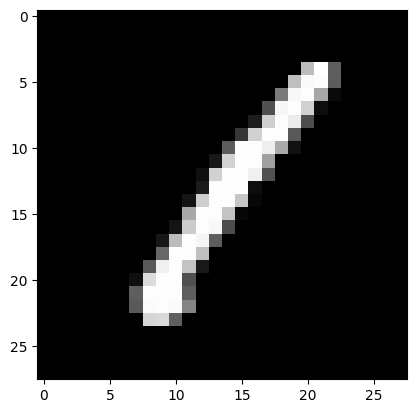

Its label is 1


In [47]:
# Extract the first image
index = 0

image_label = Y[index]
image_inline = X[:, index]  # one line representation of a 28x28(=784) pixels image 

image = np.reshape(image_inline, (28, 28))

plt.imshow(image, cmap="gray")
plt.show()
print(f"Its label is {image_label}")

In [60]:
def split_data(X, Y, Ntrain):
    '''Split the dataset in train and test'''
    d, N = X.shape

    idx = np.arange(N)
    np.random.shuffle(idx)

    train_idx = idx[:Ntrain]
    test_idx = idx[Ntrain:]

    Xtrain = X[:, train_idx]
    Ytrain = Y[train_idx]
    
    Xtest = X[:, test_idx]
    Ytest = Y[test_idx]

    return (Xtrain, Ytrain), (Xtest, Ytest)

# Test it
(Xtrain, Ytrain), (Xtest, Ytest) = split_data(X, Y, 30_000)

print(Xtrain.shape, Xtest.shape)

(784, 30000) (784, 12000)


## PCA algorithm:

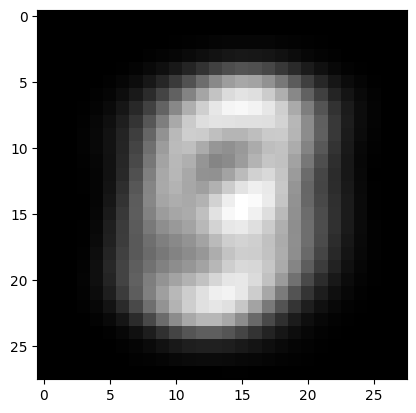

In [72]:
# 1) CENTER THE DATASET

## compute the centroid of the dataset 
## (axis=1 --> selects Xtrain.shaoe[1])
cX = np.mean(Xtrain, axis=1)    

## ATTENTION ##
## cX is (784,) and not (784, 1) so we
## have to reshape in a column vector in order to 
## compute a column by column subtraction
cX = np.reshape(cX, (784, 1))

## visulaize the 'mask'
image = np.reshape(cX, (28, 28))
plt.imshow(image, cmap="gray")
plt.show()

## Center the dataset (the one we consider ==> Train)
Xc = Xtrain - cX

In [73]:
# 2) Compute the SVD
U, s, VT = np.linalg.svd(Xc, full_matrices=False) 
# NB:   full-matrices=False make you use the cutted version
#       of the matrices so that they have the same rank as Xc

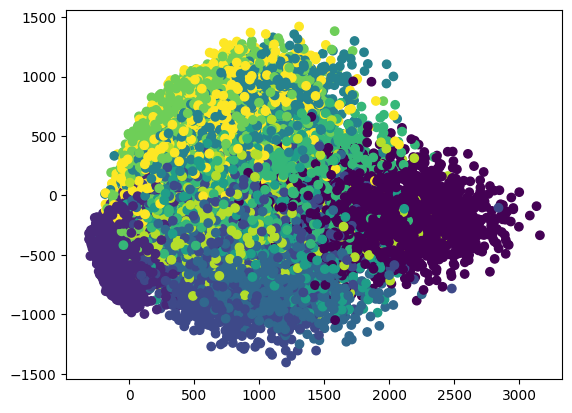

In [77]:
# 3) Compute the truncate version of SVD
k = 2   # dimension to which you want to reduce the dataset

Uk = U[:, :k]       # m x k
P = Uk.T

## Compute the projection of the dataset
Z = P @ Xtrain

## Visualize
plt.scatter(x=Z[0, :], y=Z[1, :], c=Ytrain)
plt.show()

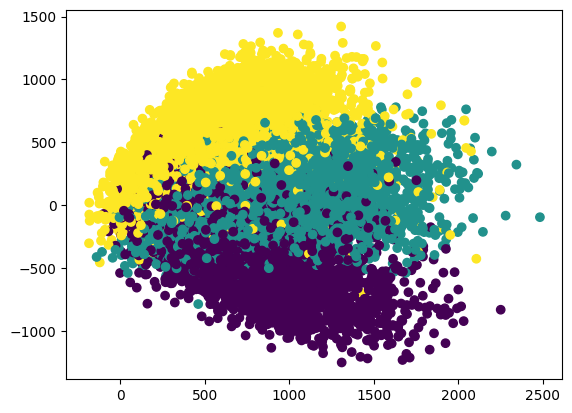

In [78]:
## Example: filter out some labels

# mine_labels = Ytrain < 2  # 0 and 1
mine_labels = (Ytrain==3) | (Ytrain==6) | (Ytrain==9)   # 3, 6, 9

## Visualize
plt.scatter(x=Z[0, mine_labels], y=Z[1, mine_labels], c=Ytrain[mine_labels])
plt.show()